# O3 H1 连续 TM PEID 结果展示

本 notebook 汇总 `results/o3_h1_peid/figure_manifest.json` 中定义的 O3 H1 实验，并展示后续连续型 transport-map PEID 结果。重点不是重新训练模型，而是复用已经落盘的特征表、响应面诊断和连续 TM PEID 输出，检查 NOx+VOC 是否在通过 Sillman 形状约束的 station-mean 模型上表现出联合信息增益。


## 实验问题

- 目标：验证夏季晴空日条件下，NOx 与 VOC 排放代理对 afternoon peak O3 的联合响应是否形成可解释的协同结构。
- 主要模型：`station_mean_poly_nox_voc`，即只使用 station-mean 层面的 `meic_NOx` 和 `meic_VOC` 拟合三阶多项式 Ridge 响应面。
- 后续估计器：连续型 affine triangular transport-map density MI，不再对 source 变量离散化。
- 主要 source set：`NOx+VOC`；对照 source set 来自 manifest 的 `tm_followup_plan`。


In [1]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Image, display

cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "results" / "o3_h1_peid").exists() else cwd.parent
RESULTS_DIR = REPO_ROOT / "results" / "o3_h1_peid"
TM_DIR = RESULTS_DIR / "tm_continuous_peid"

manifest = json.loads((RESULTS_DIR / "figure_manifest.json").read_text(encoding="utf-8"))
config = manifest["config"]
artifacts = manifest["artifacts"]
tm_results = manifest["tm_followup_results"]
print("repo:", REPO_ROOT)
print("station_scope:", config["station_scope"])
print("tm sample_count:", tm_results["config"]["sample_count"])
print("tm seeds:", tm_results["config"]["seeds"])


repo: /Users/yangmingzhe/Desktop/code/github/EISyn
station_scope: metadata_all
tm sample_count: 8192
tm seeds: [0, 1, 2, 3, 4]


## 数据与样本构造

原始 station-day 表来自 BTHSA/YRD AQI、气象和 MEIC 排放代理数据。筛选规则如下：

- 城市/站点范围：`metadata_all`，保留元数据中可与 NetCDF 数据对齐的全部站点。
- 季节范围：5-9 月。
- 日间小时：8-18 点；afternoon peak O3 从 12-18 点取最大值。
- 晴空约束：日均短波辐射 `msdwswrf >= 90`。
- 每个站点日保留至少 6 个 daylight 小时和 3 个 afternoon 小时。
- 最大 station-day 样本数为 90000，并按 split 与 station group 分层抽样。

特征中包含 MEIC 排放代理、PM2.5 日间/下午摘要、气象变量、风向风速、季节循环项、经纬度、城市编码，以及前一日 O3/PM2.5 lag 特征。注意：`meic_NOx` 与 `meic_VOC` 是排放代理，不是地面前体物浓度。


In [2]:
feature_table = pd.read_csv(artifacts["feature_sample"])
station_mean = pd.read_csv(artifacts["station_mean_feature_table"])

sample_summary = pd.DataFrame([
    {"table": "station-day feature sample", "rows": len(feature_table), "stations": feature_table["station_id"].nunique(), "cities": feature_table["city_en"].nunique()},
    {"table": "station-mean feature table", "rows": len(station_mean), "stations": station_mean["station_id"].nunique(), "cities": station_mean["city_en"].nunique()},
])
display(sample_summary)

display(
    feature_table.groupby("split")
    .agg(n_rows=("station_id", "size"), n_stations=("station_id", "nunique"), mean_o3_peak=("O3_peak", "mean"))
    .reset_index()
)

display(
    station_mean[["split", "station_group", "O3_peak", "meic_NOx", "meic_VOC"]]
    .groupby(["split", "station_group"], observed=True)
    .agg(n=("O3_peak", "size"), O3_peak_mean=("O3_peak", "mean"), NOx_mean=("meic_NOx", "mean"), VOC_mean=("meic_VOC", "mean"))
    .reset_index()
    .head(12)
)


,table,rows,stations,cities
0,station-day feature sample,90000,228,28
1,station-mean feature table,228,228,28


,split,n_rows,n_stations,mean_o3_peak
0,test,11516,228,145.948159
1,train,66704,228,139.665867
2,val,11780,228,137.647284


,split,station_group,n,O3_peak_mean,NOx_mean,VOC_mean
0,test,nox_high_voc_high,15,141.157843,3.127393,3.775928
1,test,nox_high_voc_low,3,136.267831,1.159419,0.433622
2,test,nox_low_voc_high,3,140.819782,0.773434,1.273657
3,test,nox_low_voc_low,14,142.526979,0.550494,0.525142
4,train,nox_high_voc_high,74,138.259559,2.736379,3.411330
5,train,nox_high_voc_low,7,138.375902,1.051385,0.657709
6,train,nox_low_voc_high,8,146.778918,0.773728,1.079990
7,train,nox_low_voc_low,70,140.915483,0.499884,0.493921
8,val,nox_high_voc_high,16,138.697277,3.235373,4.090223
9,val,nox_low_voc_high,2,145.087397,0.788564,1.343726


## 模型训练细节

本实验实际比较了两层模型：

1. station-day 层模型：RF 与 MLP 使用完整 `FEATURE_COLUMNS` 预测 station-day afternoon peak O3。时间切分为训练集到 2021-12-31，验证集到 2022-12-31，之后为测试集。RF 参数为 `n_estimators=260`、`min_samples_leaf=20`、`random_state=42`；MLP 为 `StandardScaler + MLPRegressor(hidden_layer_sizes=(128,64), alpha=1e-4, max_iter=1000, early_stopping=True)`。
2. station-mean 层模型：先把 station-day 表聚合成每站一行，目标为站点平均 `O3_peak`，特征为同一套特征的站点均值。station split 用 `random_state=42` 随机按站点划分。该层训练 RF、MLP 和 `poly_nox_voc`。

`poly_nox_voc` 是后续 PEID 使用的 source model。它的 pipeline 是：只取 `meic_NOx` 与 `meic_VOC` 两列，经过 `StandardScaler`，展开到三阶 `PolynomialFeatures(degree=3, include_bias=False)`，最后用 `Ridge(alpha=0.1)` 回归 station-mean `O3_peak`。选择它不是因为预测误差最低，而是因为它的 station-mean NOx-VOC 响应面通过了 Sillman 形状检查；RF/MLP 响应面未通过，因此不进入后续 PEID。


In [3]:
model_metrics = pd.read_csv(RESULTS_DIR / "model_metrics.csv")
station_mean_metrics = pd.read_csv(RESULTS_DIR / "station_mean_model_metrics.csv")
station_mean_diag = pd.read_csv(RESULTS_DIR / "station_mean_response_surface_diagnostics.csv")

print("station-day model metrics")
display(model_metrics.sort_values(["split", "model"]))

print("station-mean model metrics")
display(station_mean_metrics.sort_values(["split", "model"]))

print("station-mean all-stations Sillman diagnostics")
display(
    station_mean_diag[station_mean_diag["surface_scope"].eq("all_stations")][[
        "model", "voc_effect_at_mid_nox", "nox_low_to_mid_at_mid_voc", "nox_mid_to_high_at_mid_voc",
        "has_positive_ridge", "has_nox_sensitive_regime", "has_voc_sensitive_regime", "passes_sillman_shape_check",
        "z_range", "ridge_loglog_corr",
    ]]
)


station-day model metrics


,split,model,n_samples,rmse,mae,corr
7,test,mlp,11516,26.693401,20.802581,0.734730
6,test,rf,11516,26.092669,20.176055,0.740141
8,test,train_mean,11516,37.752379,29.506925,NaN
1,train,mlp,66704,21.111445,16.054192,0.875763
0,train,rf,66704,20.109532,14.840893,0.896416
2,train,train_mean,66704,43.706665,35.006203,NaN
4,val,mlp,11780,26.127695,20.178354,0.787000
3,val,rf,11780,25.573444,19.441580,0.794938
5,val,train_mean,11780,41.365495,32.496327,NaN


station-mean model metrics


,split,model,n_samples,rmse,mae,corr
1,test,mlp,35,12.804566,9.334884,3.259645e-01
2,test,poly_nox_voc,35,6.392308,5.137588,5.311844e-01
0,test,rf,35,1.472979,1.138415,9.819033e-01
3,test,train_mean,35,7.378804,5.837679,-8.965755e-16
5,train,mlp,159,5.729312,3.797701,8.398792e-01
6,train,poly_nox_voc,159,8.273289,6.462209,3.464308e-01
4,train,rf,159,1.486690,0.915482,9.858490e-01
7,train,train_mean,159,8.819343,6.784171,NaN
9,val,mlp,34,12.311537,9.247555,3.016346e-01
10,val,poly_nox_voc,34,8.603197,6.592736,1.769523e-01


station-mean all-stations Sillman diagnostics


,model,voc_effect_at_mid_nox,nox_low_to_mid_at_mid_voc,nox_mid_to_high_at_mid_voc,has_positive_ridge,has_nox_sensitive_regime,has_voc_sensitive_regime,passes_sillman_shape_check,z_range,ridge_loglog_corr
0,rf,0.017764,-0.117251,-0.007397,False,False,False,False,0.150664,NaN
5,mlp,-5.214340,-3.132767,-8.707493,False,False,False,False,16.524795,NaN
10,poly_nox_voc,0.143502,0.610520,-12.475299,True,True,True,True,33.343007,0.981625


## 响应面展示

下图是通过形状检查后保留的 station-mean `poly_nox_voc` 响应面。它在全站点层面呈现正 ridge、NOx-sensitive regime 和 VOC-sensitive regime，因此被作为后续连续 TM PEID 的 source model。


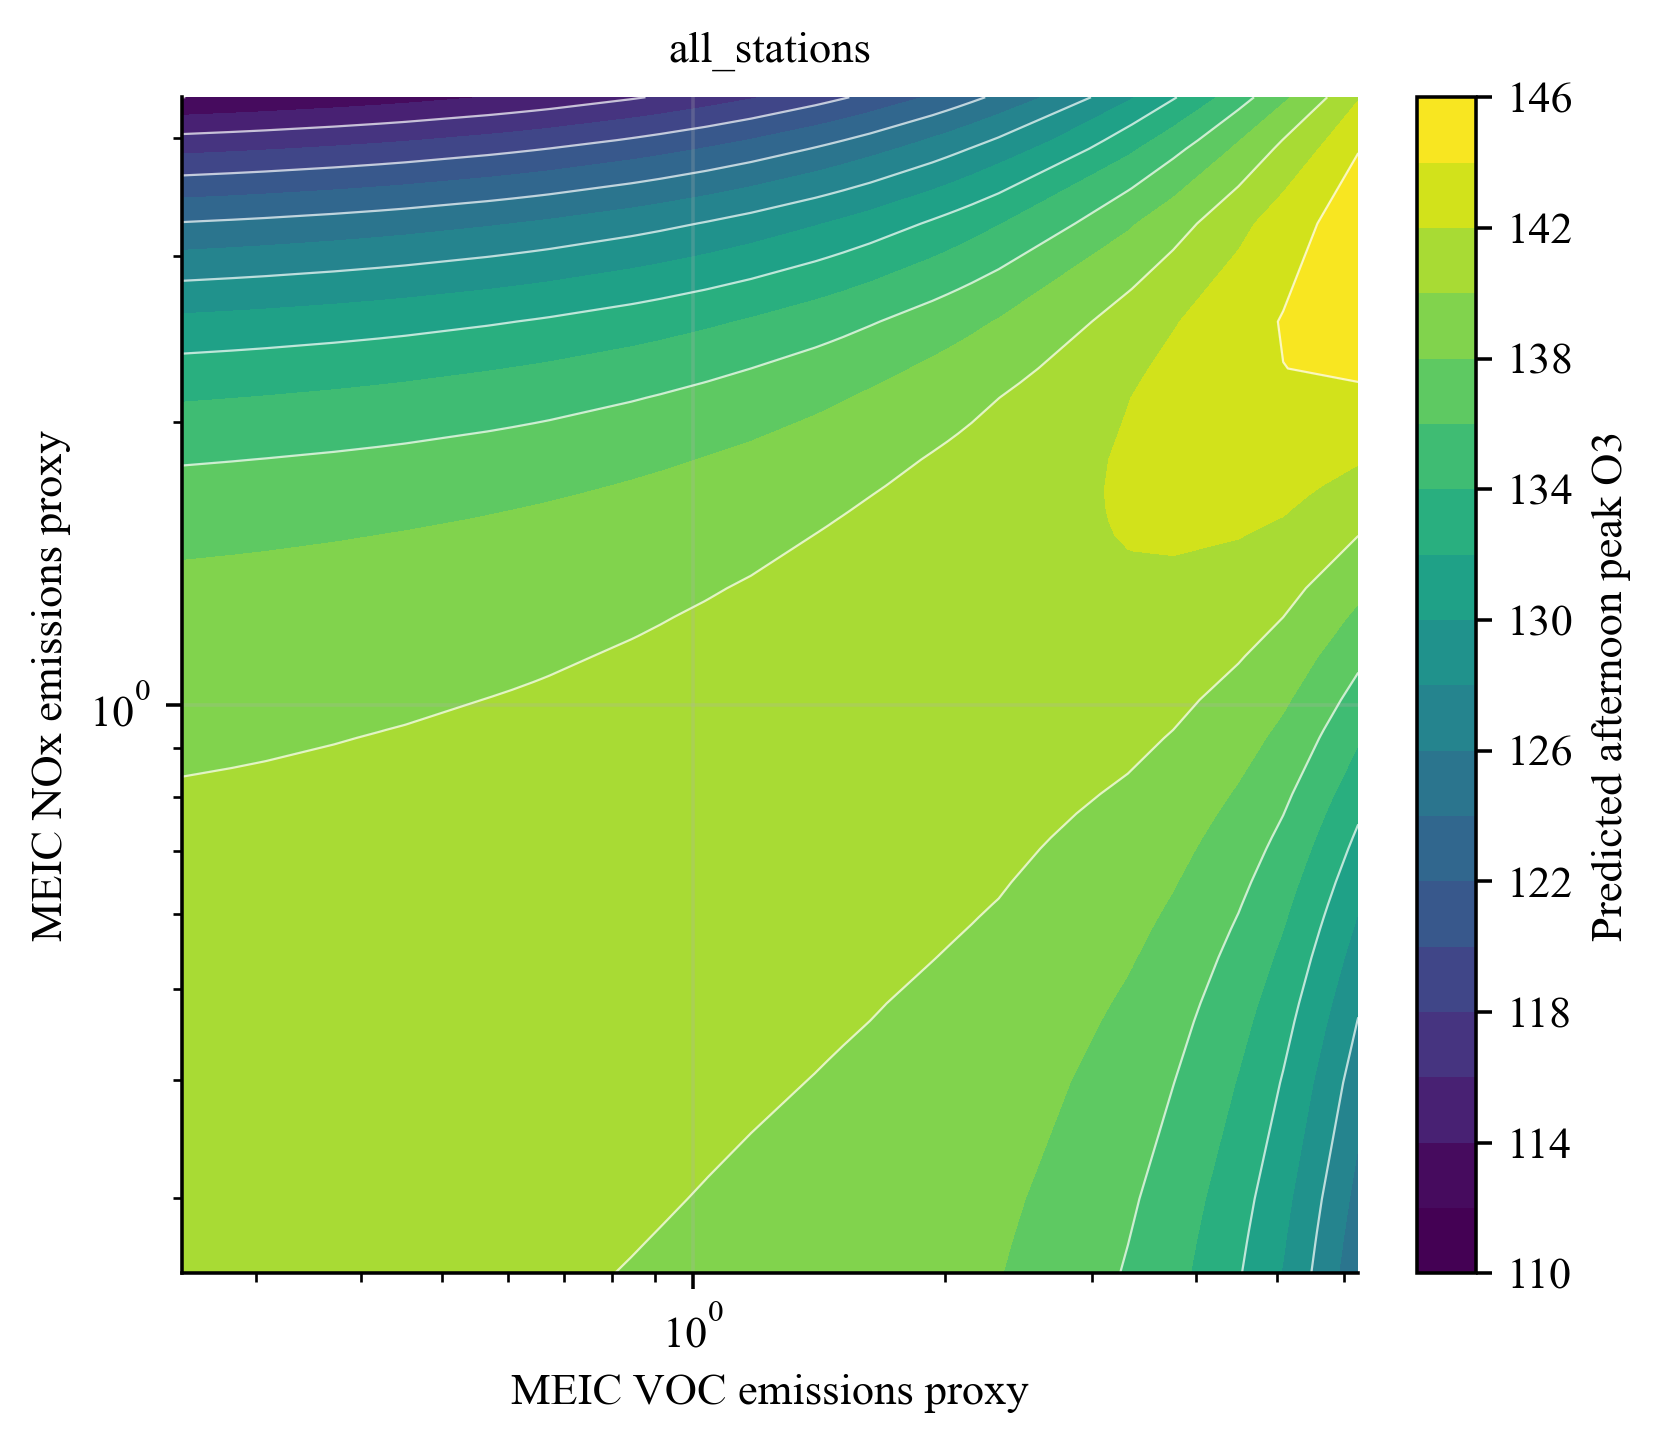

In [4]:
display(Image(filename=str(RESULTS_DIR / "station_mean_peak_o3_response_surface_poly_nox_voc.png")))


## 连续 TM PEID 后续实验

后续实验严格使用 manifest 中的 `tm_followup_plan`：

- estimator：`transport_map_continuous_peid`
- source model：`station_mean_poly_nox_voc`
- target：`O3hat`
- primary source set：`NOx+VOC`
- comparison source sets：`NOx+Temp`、`NOx+RH`、`VOC+Temp`、`VOC+SSR`、`Temp+RH`、`NOx+VOC+Temp`
- 不离散化 source 变量。

实现上，每个 source set 在 station-mean empirical 5%-95% 支持范围内采样，其他特征固定为 station-mean 中位数；用 `poly_nox_voc` 得到 `O3hat`，再用 affine triangular transport-map density MI 估计联合 MI、单变量 MI、相对 best individual 的增益，以及 `joint MI - sum(individual MI)` 的 net synergy。每个 source set 使用 5 个 seed，每个 seed 8192 个样本。


In [5]:
tm_summary = pd.read_csv(TM_DIR / "tm_continuous_peid_summary.csv")
tm_runs = pd.read_csv(TM_DIR / "tm_continuous_peid_seed_runs.csv")

display(tm_summary[[
    "sources", "n_seeds", "sample_count", "joint_mi_mean_nats", "joint_mi_sd_nats",
    "gain_over_best_individual_mean_nats", "gain_over_best_individual_sd_nats",
    "net_synergy_mean_nats", "net_synergy_sd_nats",
]])

primary = tm_summary[tm_summary["sources"].eq("NOx+VOC")].iloc[0]
print(f"NOx+VOC joint MI = {primary['joint_mi_mean_nats']:.4f} nats")
print(f"NOx+VOC gain over best individual = {primary['gain_over_best_individual_mean_nats']:.4f} nats")
print(f"NOx+VOC net synergy = {primary['net_synergy_mean_nats']:.4f} nats")


,sources,n_seeds,sample_count,joint_mi_mean_nats,joint_mi_sd_nats,gain_over_best_individual_mean_nats,gain_over_best_individual_sd_nats,net_synergy_mean_nats,net_synergy_sd_nats
0,NOx+VOC+Temp,5,8192,0.269185,0.009464,0.013153,0.002870,0.005078,0.001777
1,NOx+VOC,5,8192,0.267074,0.010735,0.011999,0.002545,0.004577,0.001880
2,NOx+Temp,5,8192,0.998096,0.007082,-0.000002,0.000075,-0.000012,0.000061
3,NOx+RH,5,8192,0.994161,0.005041,-0.000005,0.000105,-0.000012,0.000089
4,Temp+RH,5,8192,0.000079,0.000119,-0.000018,0.000025,-0.000018,0.000025
5,VOC+SSR,5,8192,0.160819,0.003239,-0.000027,0.000045,-0.000060,0.000060
6,VOC+Temp,5,8192,0.163305,0.007237,-0.000050,0.000013,-0.000058,0.000019


NOx+VOC joint MI = 0.2671 nats
NOx+VOC gain over best individual = 0.0120 nats
NOx+VOC net synergy = 0.0046 nats


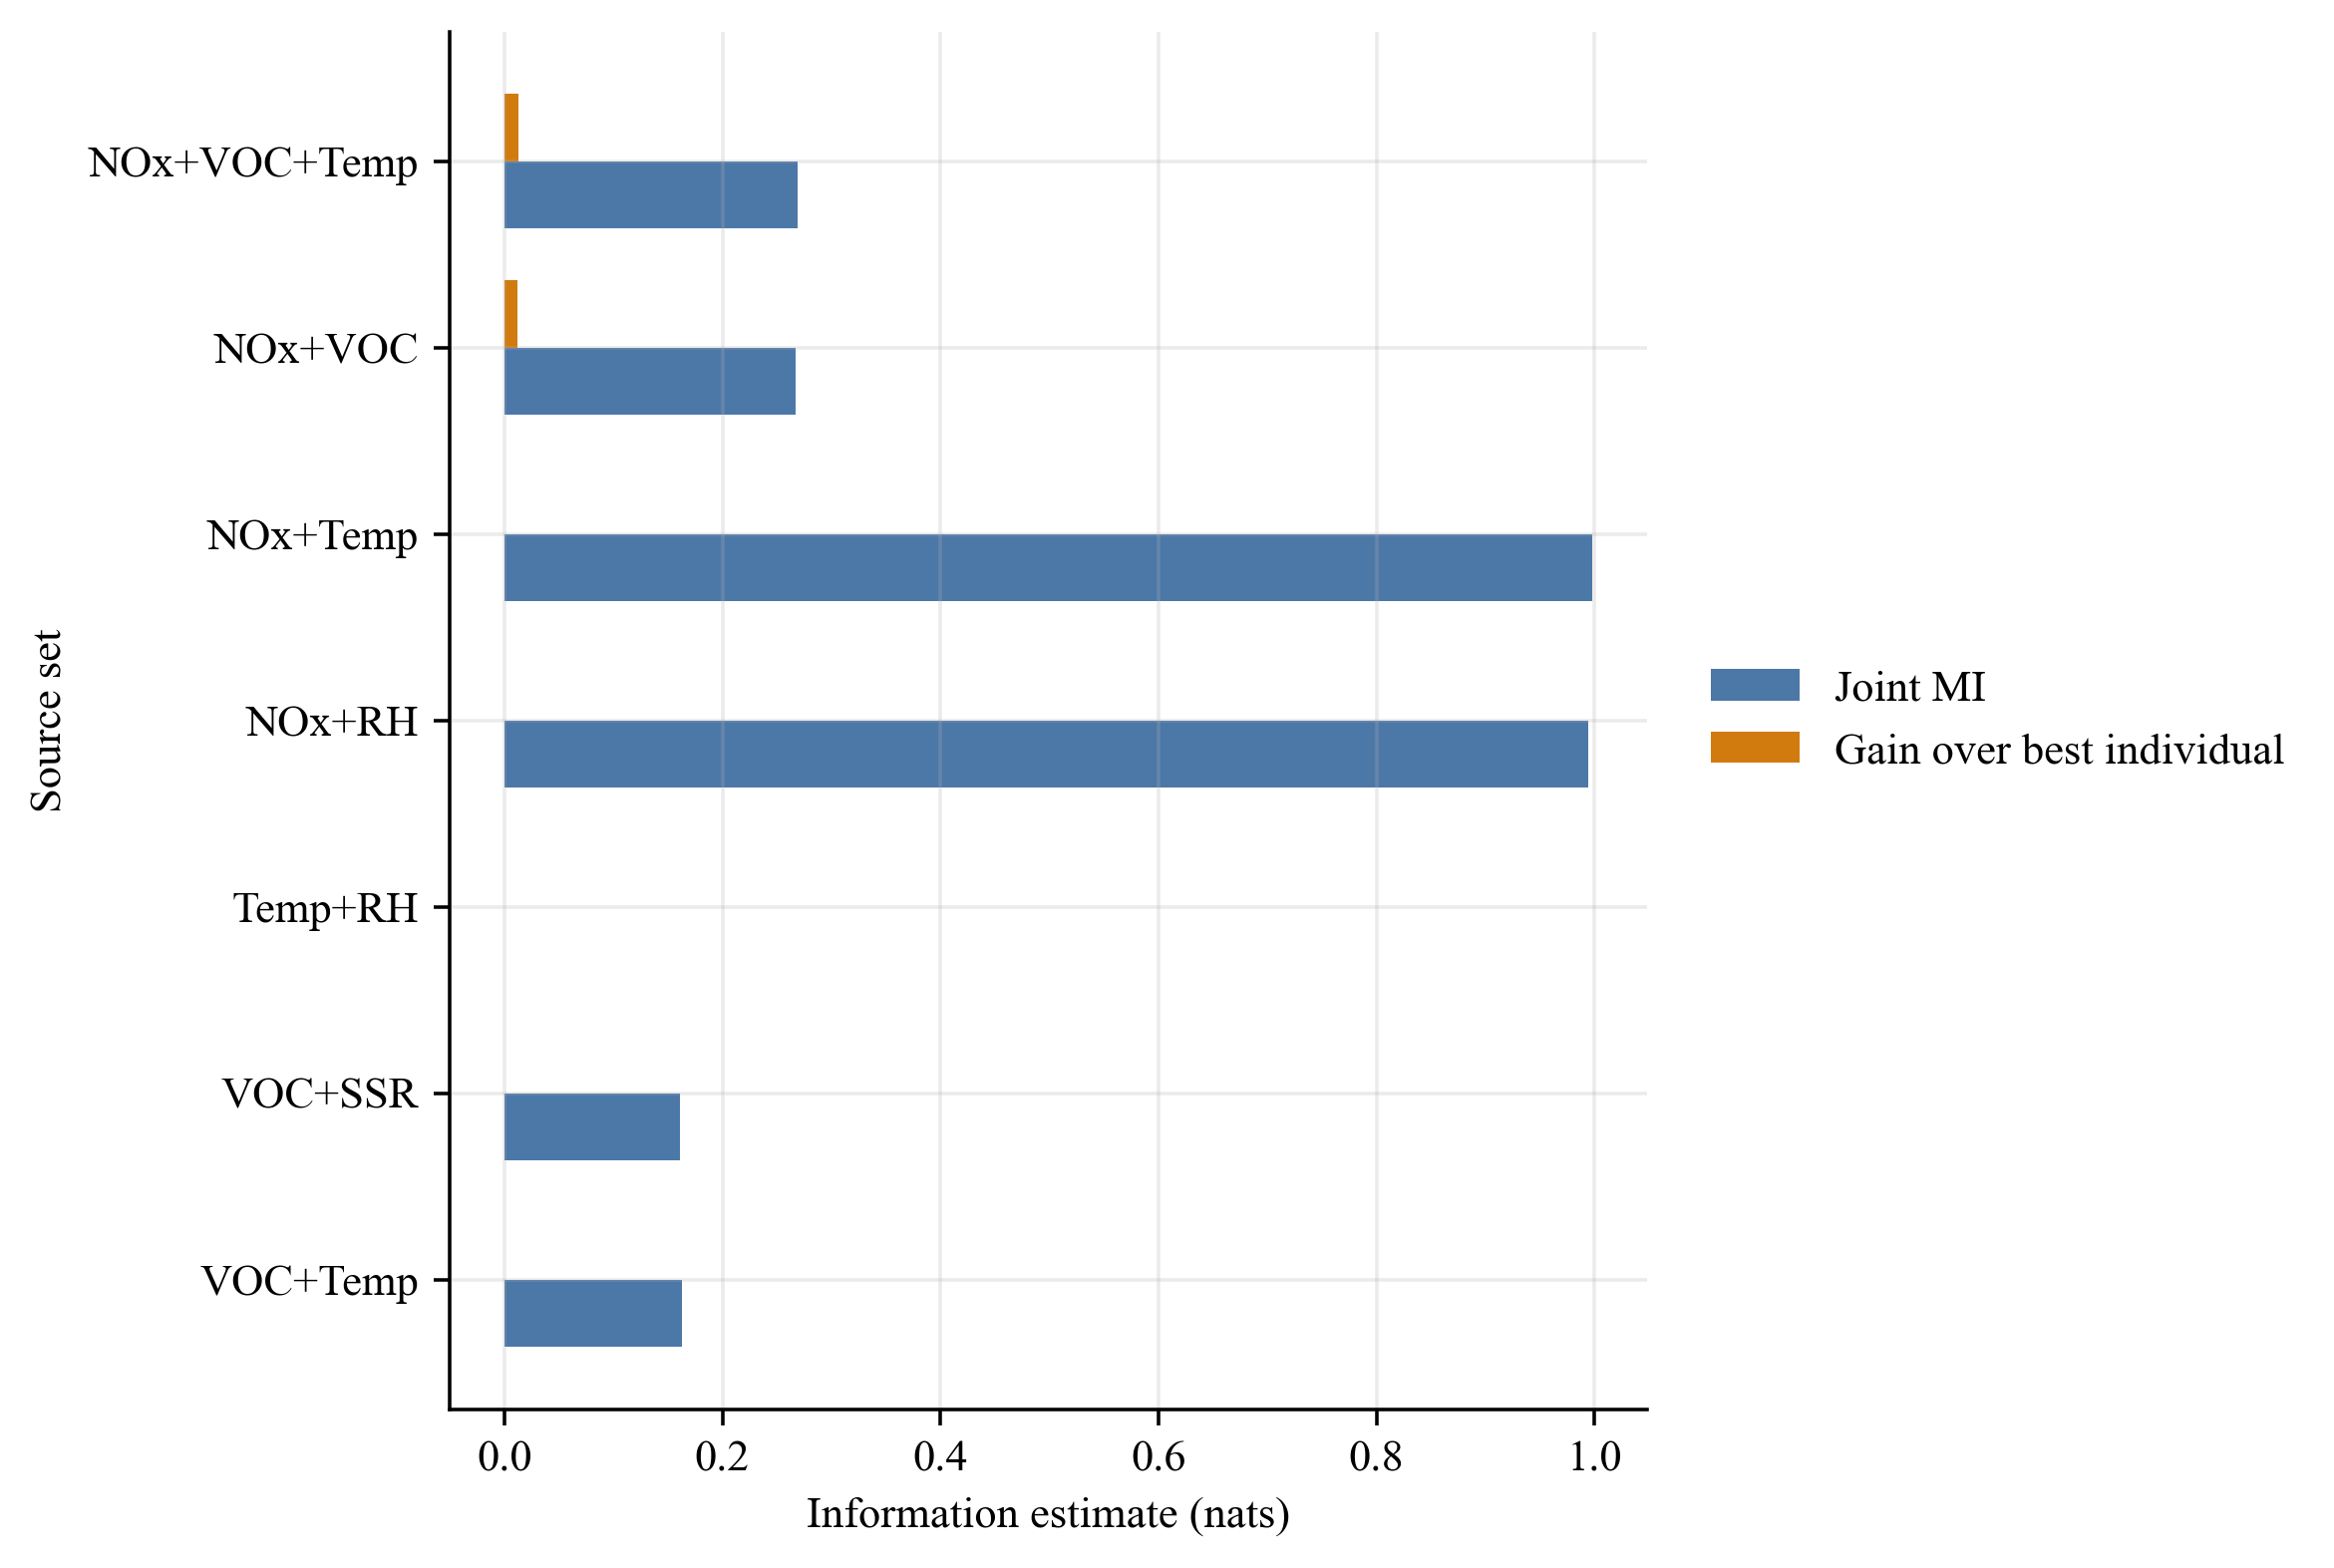

In [6]:
display(Image(filename=str(TM_DIR / "tm_continuous_peid_summary.png")))


## 结果解读

- `NOx+VOC` 的 joint MI 约为 0.2671 nats，相对 best individual 的增益约为 0.0120 nats，net synergy 约为 0.0046 nats。说明在该 station-mean 多项式响应面上，NOx 与 VOC 的连续联合扰动提供了小但稳定的联合信息增量。
- `NOx+VOC+Temp` 的 gain 略高，约为 0.0132 nats；但由于 source model 只显式使用 NOx 与 VOC，Temp 在这里主要通过采样和估计器噪声表现为对照项，不应解释为独立物理驱动。
- `NOx+Temp` 与 `NOx+RH` 的 joint MI 很高，是因为 `NOx` 本身支配了该响应面；它们相对 best individual 的 gain 接近 0，说明加入气象负控变量没有带来稳定协同增益。
- RF 与 MLP 虽然在预测误差上有不同表现，但其 station-mean 响应面未通过 Sillman 形状检查，因此没有作为后续 PEID 的依据。这个筛选避免把不符合臭氧化学响应形态的黑箱表面继续解释为 NOx-VOC 协同。


## 可复现路径

- 主 manifest：`results/o3_h1_peid/figure_manifest.json`
- station-mean 特征表：`exp/cache/o3_h1_peid/station_mean_peak_o3_feature_table.csv`
- 连续 TM PEID 脚本：`scripts/run_o3_h1_tm_peid.py`
- 连续 TM PEID 输出：`results/o3_h1_peid/tm_continuous_peid/`

若要复跑后续实验，在仓库根目录执行：

```bash
python3 scripts/run_o3_h1_tm_peid.py
```
